# Store Sales Analysis Dashboard — Exploratory Data Analysis

**Objective:** Explore the cleaned retail sales dataset to uncover sales trends, customer
purchasing behavior, product performance, profitability, and regional performance ahead of
building the Power BI dashboard.

**Dataset:** `../Dataset/Cleaned_Data.csv` (output of `data_cleaning.py`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../Dataset/Cleaned_Data.csv", parse_dates=["Order Date", "Ship Date"])
df.shape

(15200, 28)

## 1. Data Overview & Summary Statistics

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15200 entries, 0 to 15199
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           15200 non-null  str           
 1   Order Date         15200 non-null  datetime64[us]
 2   Ship Date          15200 non-null  datetime64[us]
 3   Customer ID        15200 non-null  str           
 4   Customer Name      15200 non-null  str           
 5   Segment            15200 non-null  str           
 6   City               15200 non-null  str           
 7   State              15200 non-null  str           
 8   Region             15200 non-null  str           
 9   Product Category   15200 non-null  str           
 10  Sub Category       15200 non-null  str           
 11  Product Name       15200 non-null  str           
 12  Sales              15200 non-null  float64       
 13  Quantity           15200 non-null  int64         
 14  Discount         

In [3]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Sales,15200.0,1481.909253,1989.714514,0.7600,174.9600,680.13000,2054.7375,21282.2500
Quantity,15200.0,6.527039,3.458579,1.0000,3.0000,7.00000,10.0000,12.0000
Discount,15200.0,0.179789,0.174430,0.0000,0.0000,0.15000,0.3000,0.5000
Profit,15200.0,164.848924,608.700645,-16884.3200,-5.2525,36.80000,244.4850,6396.5800
Shipping Cost,15200.0,30.861489,16.630211,2.0000,16.6000,30.68000,45.1400,60.0000
Order Year,15200.0,2024.533224,0.961090,2023.0000,2024.0000,2025.00000,2025.0000,2026.0000
Order Month,15200.0,6.587961,3.457166,1.0000,4.0000,7.00000,10.0000,12.0000
Order Quarter,15200.0,2.524605,1.119271,1.0000,2.0000,3.00000,4.0000,4.0000
Shipping Days,15200.0,3.052697,60.654245,-323.0000,2.0000,3.00000,5.0000,331.0000
Profit Margin,15200.0,0.108474,0.253997,-9.9075,-0.0286,0.14455,0.2651,2.7836


## 2. Missing Value Analysis (post-cleaning sanity check)

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0]
print("Remaining missing values:" if len(missing) else "No missing values remain after cleaning.")
missing

No missing values remain after cleaning.


Series([], dtype: int64)

## 3. Correlation Analysis

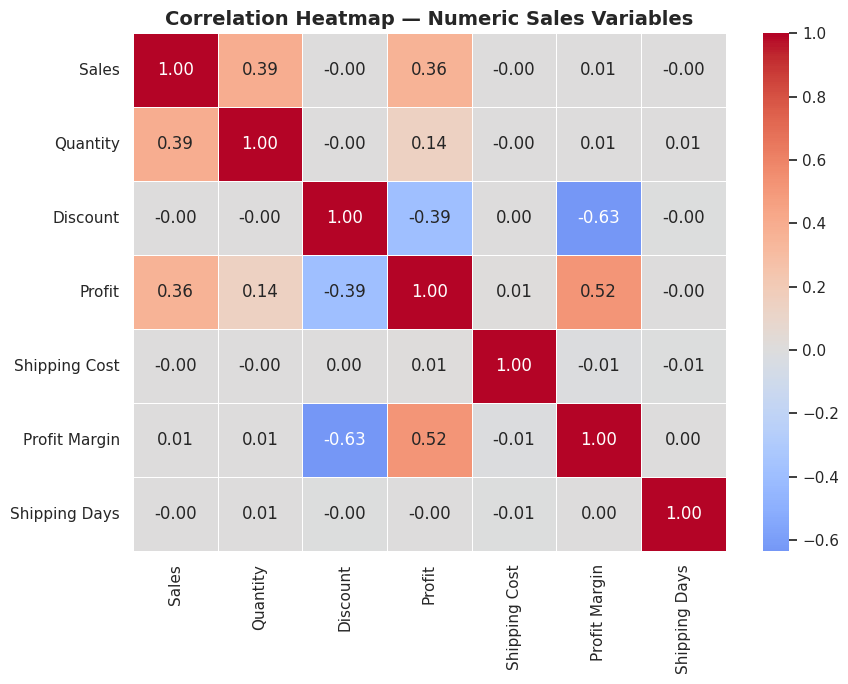

In [5]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Profit Margin", "Shipping Days"]
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Sales Variables")
plt.tight_layout()
plt.savefig("eda_images/01_correlation_heatmap.png", dpi=120)
plt.show()

## 4. Sales & Profit Distributions

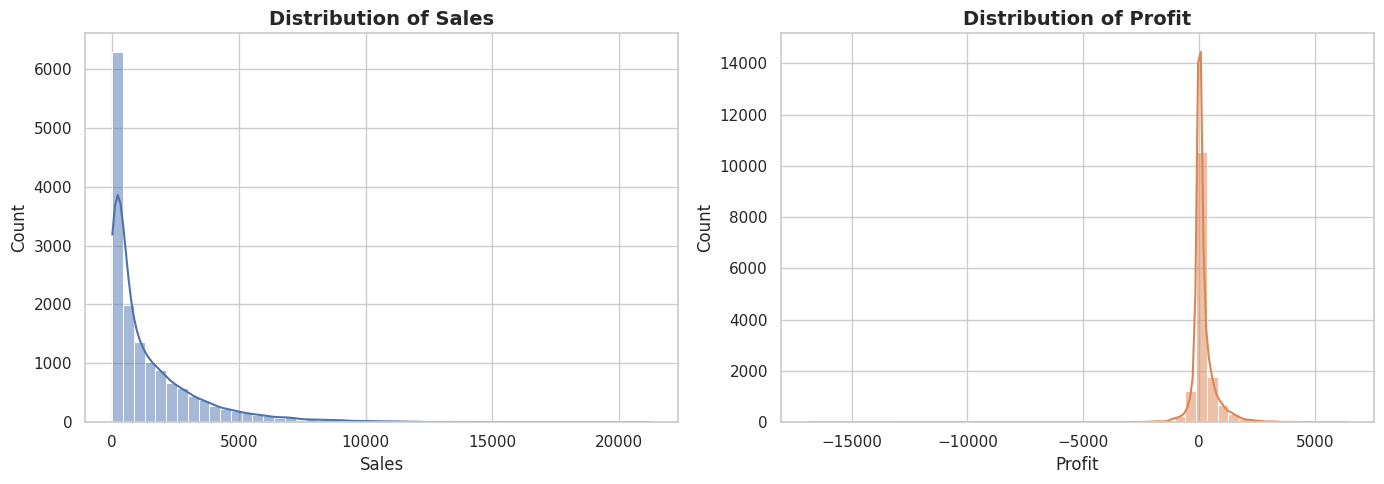

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Sales")
sns.histplot(df["Profit"], bins=50, kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Profit")
plt.tight_layout()
plt.savefig("eda_images/02_sales_profit_distribution.png", dpi=120)
plt.show()

/tmp/ipykernel_632/3763508343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Product Category", y="Sales", data=df, ax=axes[0], palette="Set2")
/tmp/ipykernel_632/3763508343.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Product Category", y="Profit", data=df, ax=axes[1], palette="Set2")


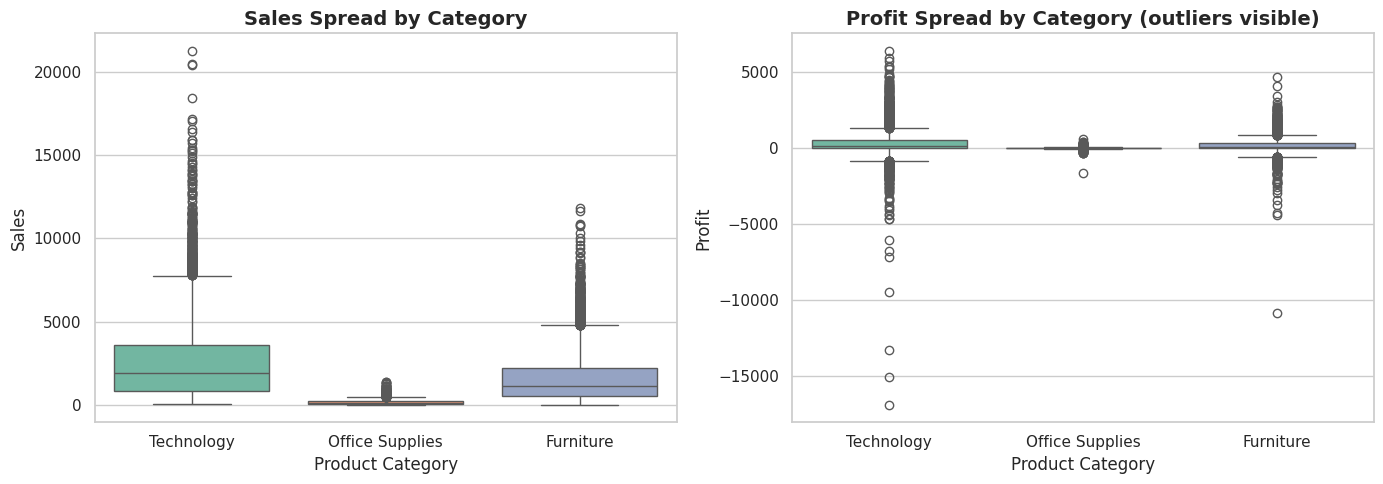

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Product Category", y="Sales", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Sales Spread by Category")
sns.boxplot(x="Product Category", y="Profit", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Profit Spread by Category (outliers visible)")
plt.tight_layout()
plt.savefig("eda_images/03_boxplots_category.png", dpi=120)
plt.show()

## 5. Monthly & Yearly Sales Trend

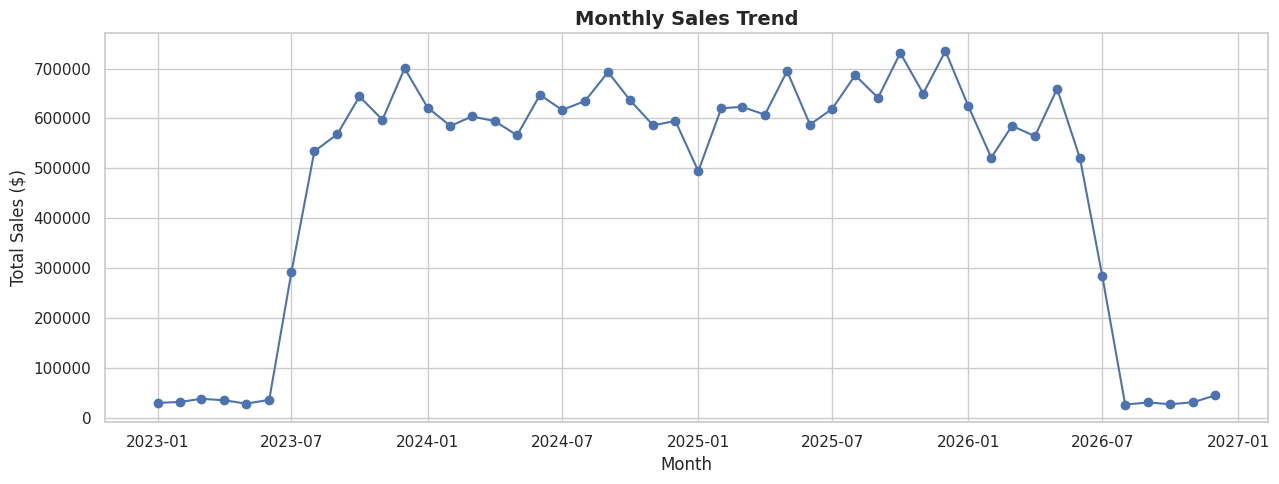

In [8]:
monthly = df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(monthly["Order Date"], monthly["Sales"], marker="o", color="#4C72B0")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("eda_images/04_monthly_sales_trend.png", dpi=120)
plt.show()

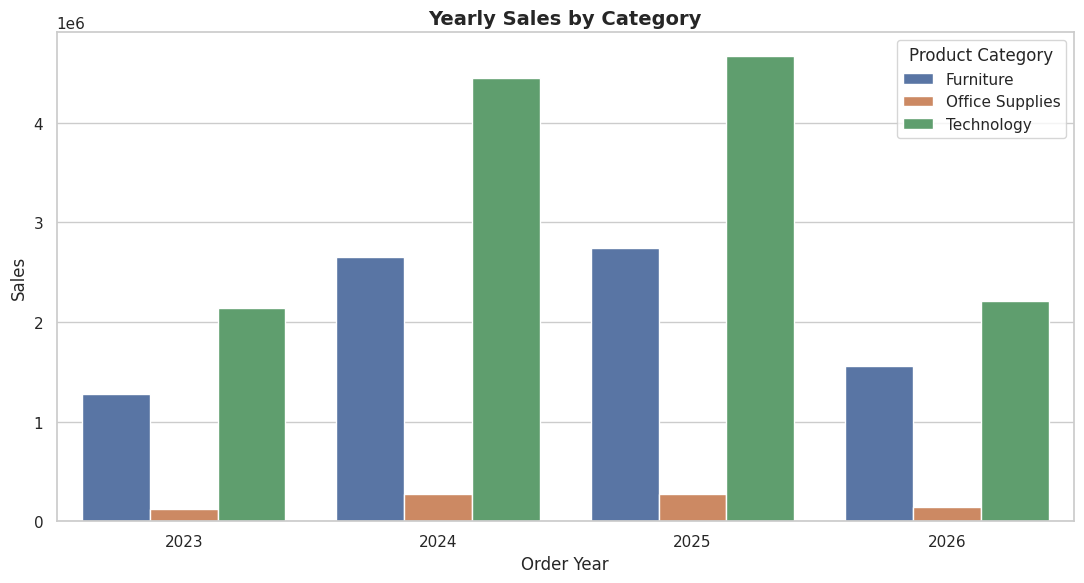

In [9]:
yearly_cat = df.groupby(["Order Year", "Product Category"])["Sales"].sum().reset_index()
plt.figure(figsize=(11, 6))
sns.barplot(data=yearly_cat, x="Order Year", y="Sales", hue="Product Category")
plt.title("Yearly Sales by Category")
plt.tight_layout()
plt.savefig("eda_images/05_yearly_sales_by_category.png", dpi=120)
plt.show()

## 6. Category & Sub-Category Performance

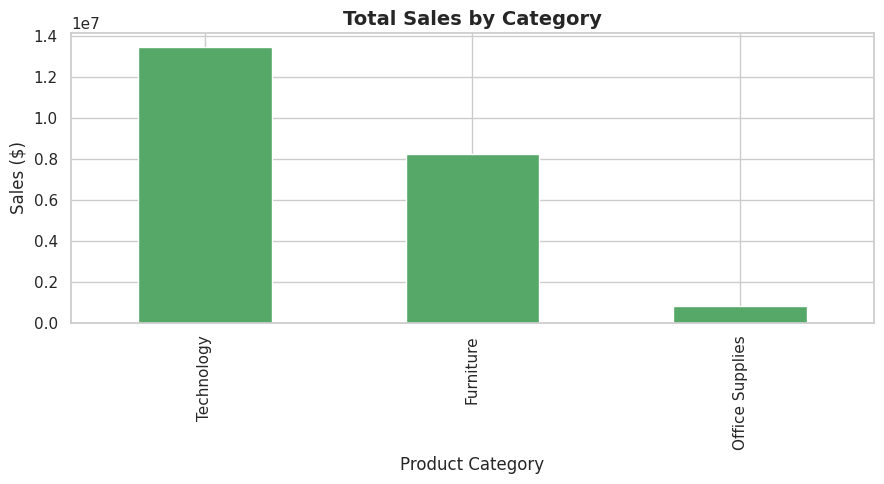

,Sales,Profit
Product Category,,
Technology,13475340.41,1501646.20
Furniture,8226063.98,912149.10
Office Supplies,823616.26,91908.35


In [10]:
cat_perf = df.groupby("Product Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
plt.figure(figsize=(9, 5))
cat_perf["Sales"].plot(kind="bar", color="#55A868")
plt.title("Total Sales by Category")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("eda_images/06_sales_by_category.png", dpi=120)
plt.show()
cat_perf

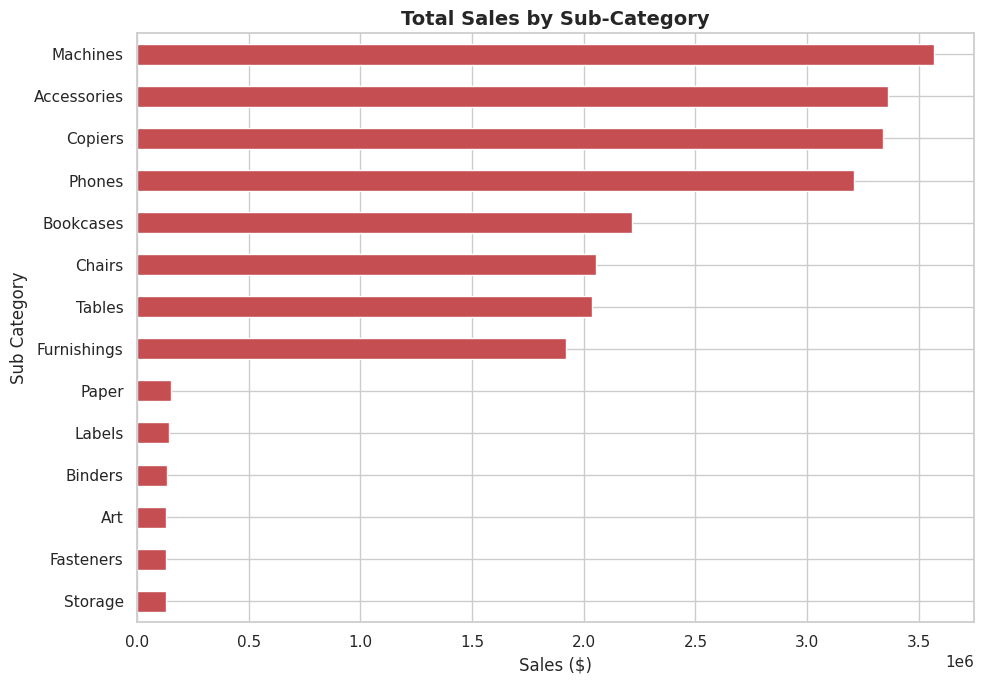

In [11]:
subcat_perf = df.groupby("Sub Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
subcat_perf.plot(kind="barh", color="#C44E52")
plt.title("Total Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("eda_images/07_sales_by_subcategory.png", dpi=120)
plt.show()

## 7. Profitability Analysis

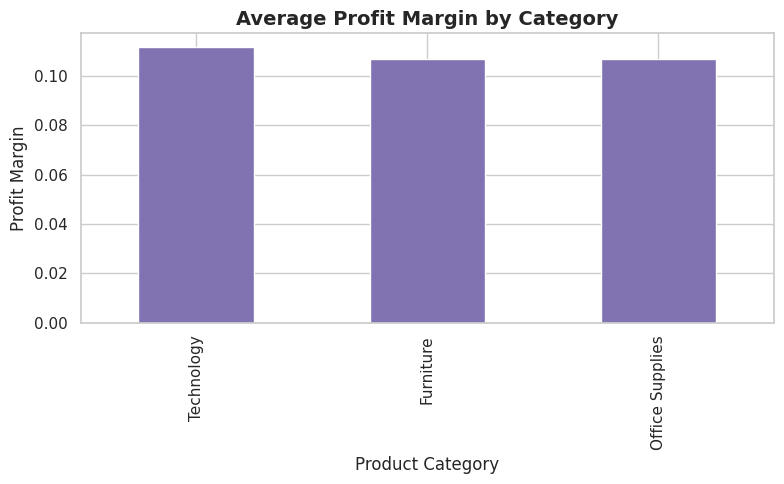

In [12]:
profit_margin_cat = df.groupby("Product Category")["Profit Margin"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
profit_margin_cat.plot(kind="bar", color="#8172B2")
plt.title("Average Profit Margin by Category")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.savefig("eda_images/08_profit_margin_by_category.png", dpi=120)
plt.show()

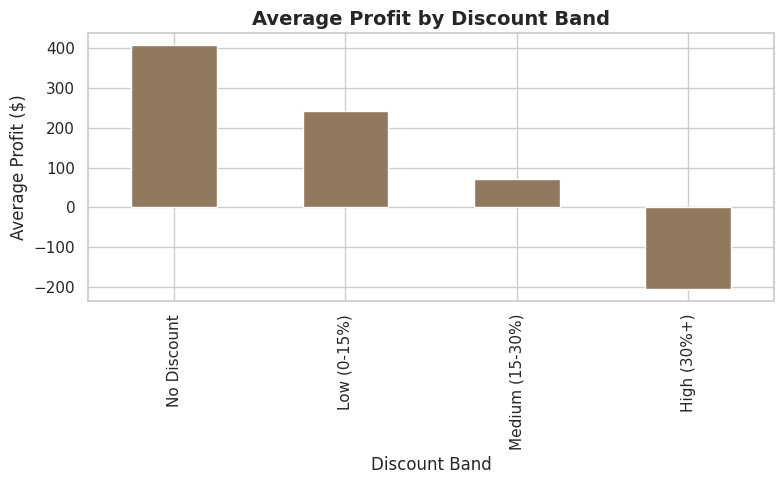

In [13]:
discount_profit = df.groupby("Discount Band", observed=True)["Profit"].mean().reindex(
    ["No Discount", "Low (0-15%)", "Medium (15-30%)", "High (30%+)"])
plt.figure(figsize=(8, 5))
discount_profit.plot(kind="bar", color="#937860")
plt.title("Average Profit by Discount Band")
plt.ylabel("Average Profit ($)")
plt.tight_layout()
plt.savefig("eda_images/09_profit_by_discount_band.png", dpi=120)
plt.show()

## 8. Regional Performance

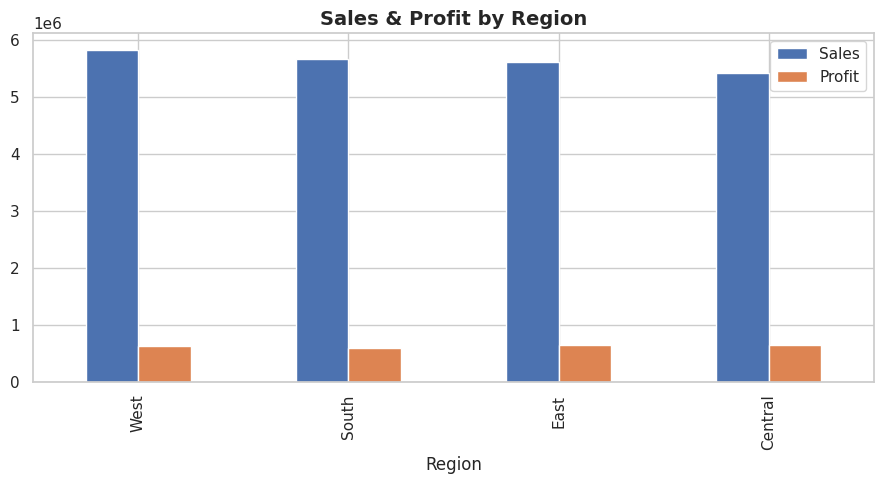

In [14]:
region_perf = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
region_perf.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
plt.title("Sales & Profit by Region")
plt.tight_layout()
plt.savefig("eda_images/10_sales_profit_by_region.png", dpi=120)
plt.show()

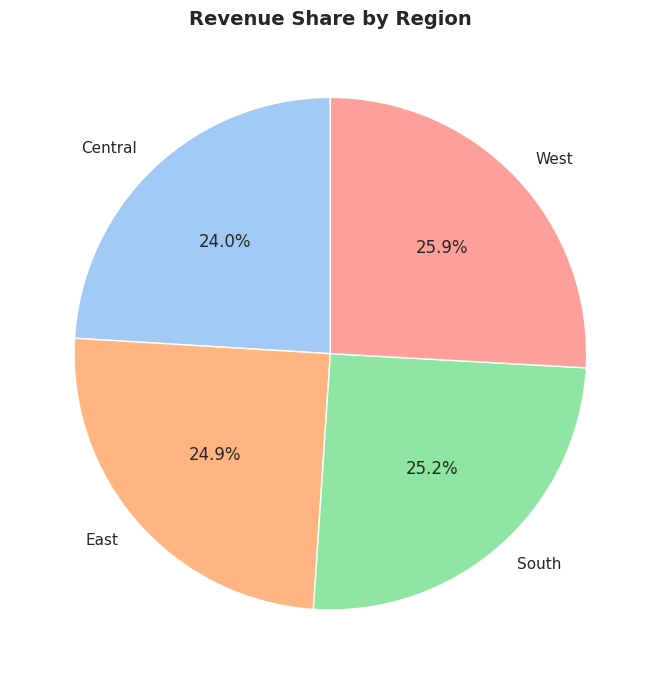

In [15]:
plt.figure(figsize=(7, 7))
df.groupby("Region")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%", startangle=90,
                                          colors=sns.color_palette("pastel"))
plt.title("Revenue Share by Region")
plt.ylabel("")
plt.tight_layout()
plt.savefig("eda_images/11_revenue_share_region_pie.png", dpi=120)
plt.show()

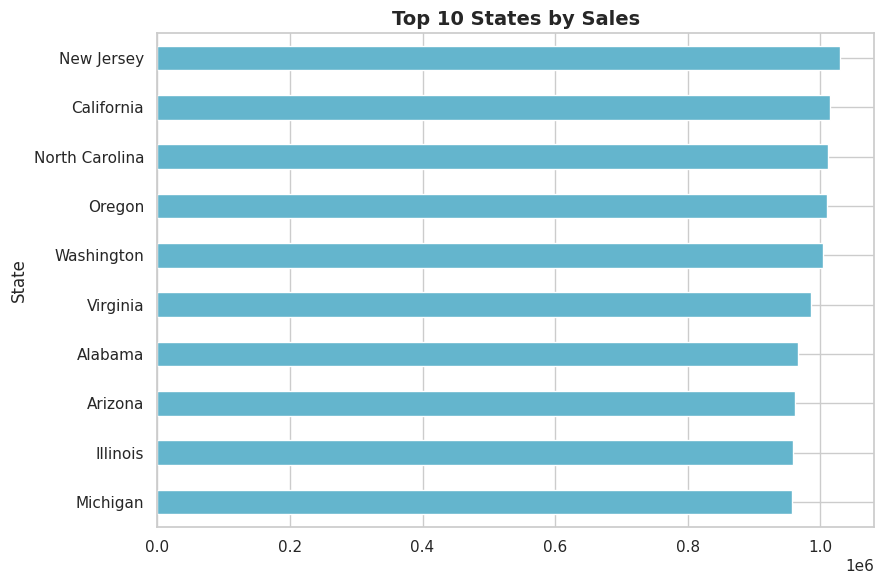

In [16]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 6))
top_states.plot(kind="barh", color="#64B5CD")
plt.title("Top 10 States by Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("eda_images/12_top10_states.png", dpi=120)
plt.show()

## 9. Customer Segmentation

<Figure size 800x500 with 0 Axes>

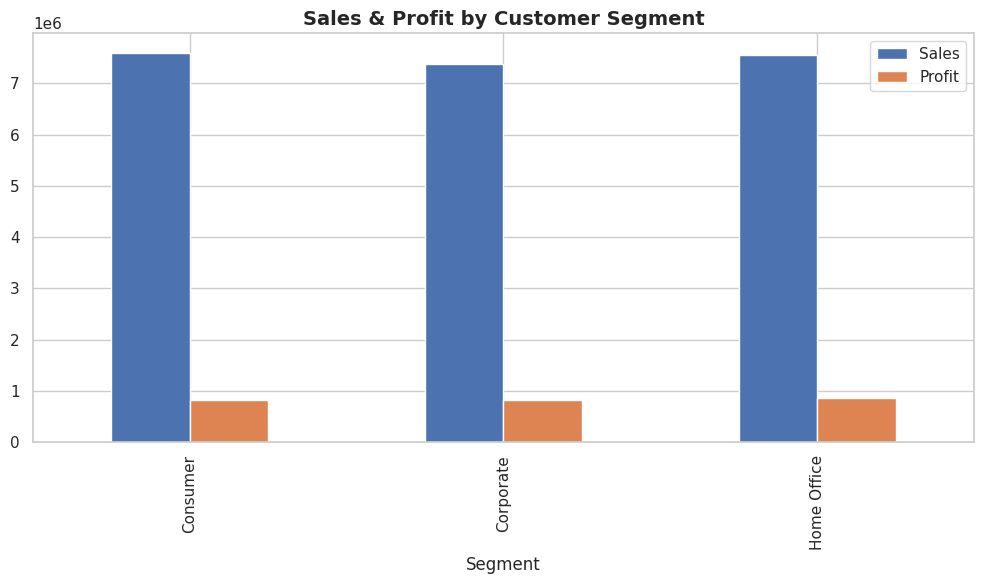

In [17]:
seg_perf = df.groupby("Segment")[["Sales", "Profit"]].sum()
plt.figure(figsize=(8, 5))
seg_perf.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Sales & Profit by Customer Segment")
plt.tight_layout()
plt.savefig("eda_images/13_segment_performance.png", dpi=120)
plt.show()

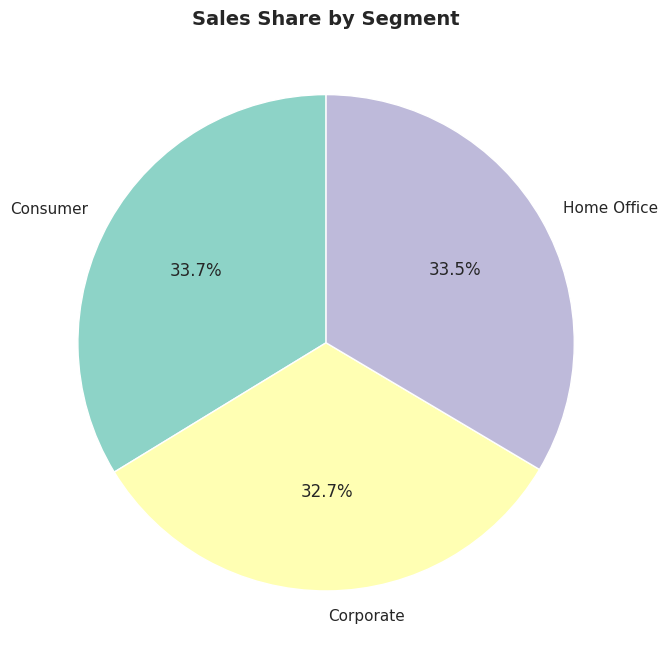

In [18]:
plt.figure(figsize=(7, 7))
df.groupby("Segment")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%", startangle=90,
                                           colors=sns.color_palette("Set3"))
plt.title("Sales Share by Segment")
plt.ylabel("")
plt.tight_layout()
plt.savefig("eda_images/14_segment_share_donut.png", dpi=120)
plt.show()

<Figure size 1000x600 with 0 Axes>

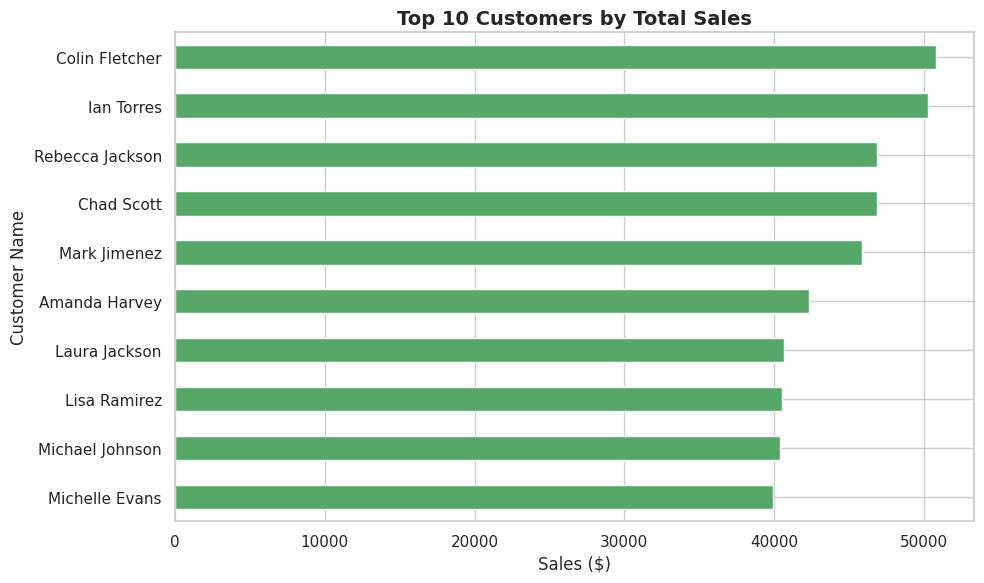

In [19]:
cust_value = df.groupby(["Customer ID", "Customer Name"])["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
cust_value.reset_index().plot(kind="barh", x="Customer Name", y="Sales", legend=False, color="#55A868")
plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Sales ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("eda_images/15_top10_customers.png", dpi=120)
plt.show()

## 10. Top & Worst Performing Products

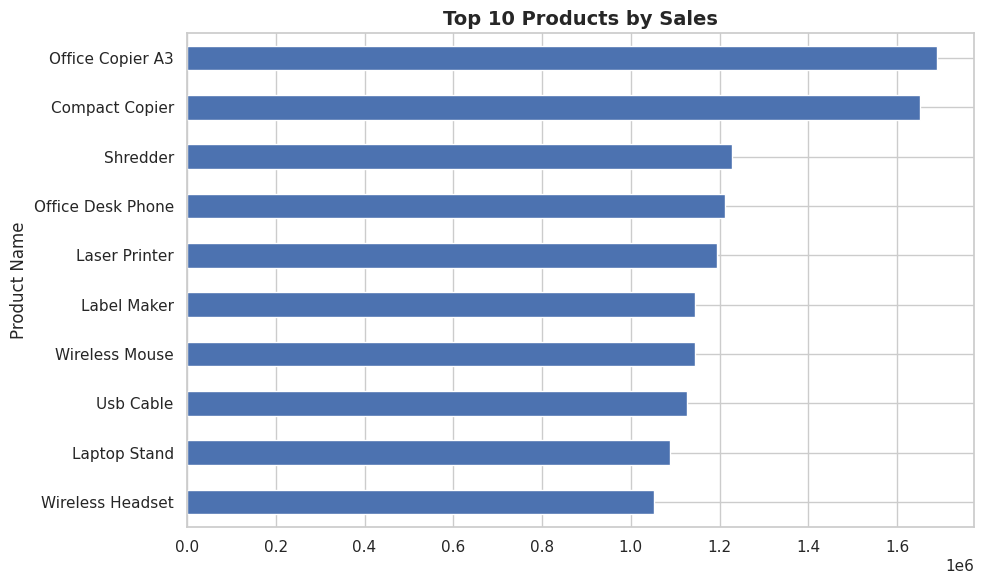

In [20]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="#4C72B0")
plt.title("Top 10 Products by Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("eda_images/16_top10_products.png", dpi=120)
plt.show()

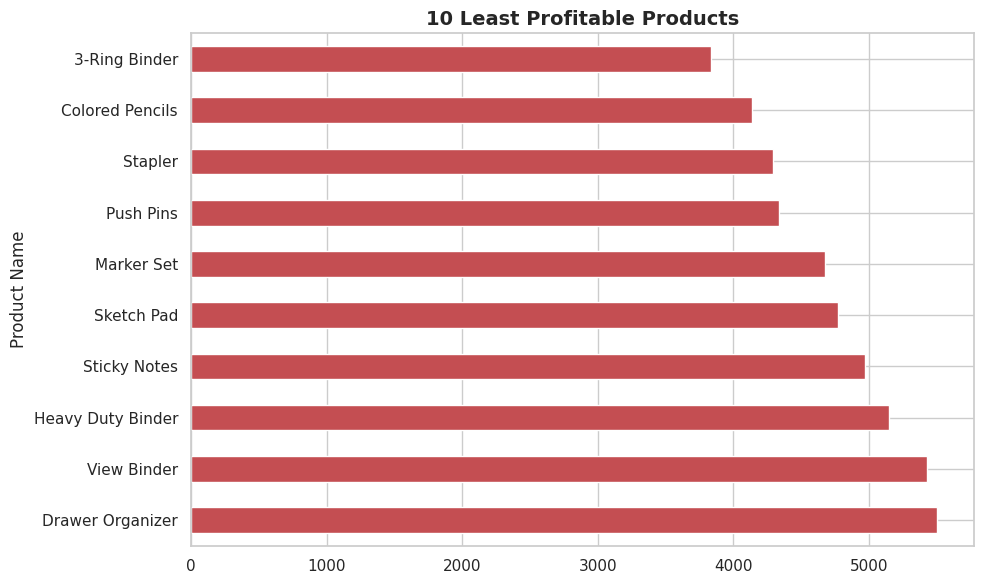

In [21]:
worst_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)
plt.figure(figsize=(10, 6))
worst_products.plot(kind="barh", color="#C44E52")
plt.title("10 Least Profitable Products")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("eda_images/17_worst10_products_profit.png", dpi=120)
plt.show()

## 11. Order Priority & Payment Mode

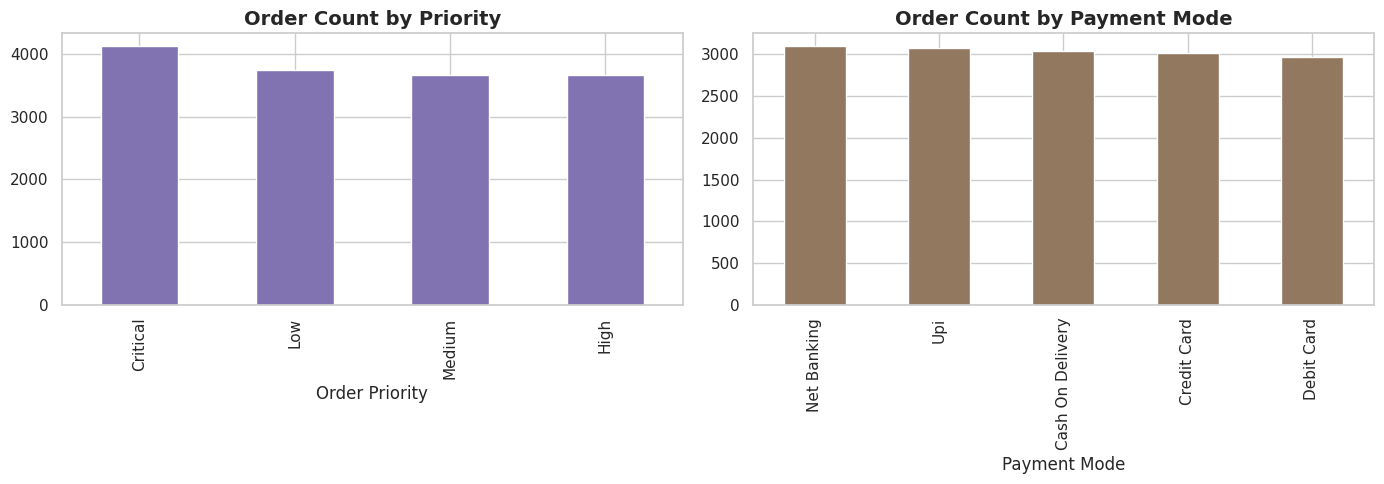

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["Order Priority"].value_counts().plot(kind="bar", ax=axes[0], color="#8172B2")
axes[0].set_title("Order Count by Priority")
df["Payment Mode"].value_counts().plot(kind="bar", ax=axes[1], color="#937860")
axes[1].set_title("Order Count by Payment Mode")
plt.tight_layout()
plt.savefig("eda_images/18_priority_payment_counts.png", dpi=120)
plt.show()

## 12. Shipping Performance

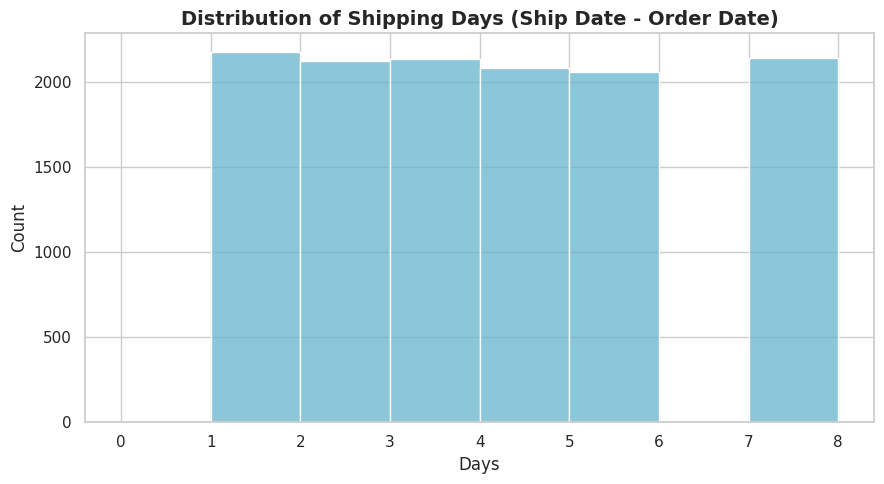

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Shipping Days"], bins=range(0, 9), color="#64B5CD")
plt.title("Distribution of Shipping Days (Ship Date - Order Date)")
plt.xlabel("Days")
plt.tight_layout()
plt.savefig("eda_images/19_shipping_days_distribution.png", dpi=120)
plt.show()

## 13. Discount vs Profit Relationship (Scatter)

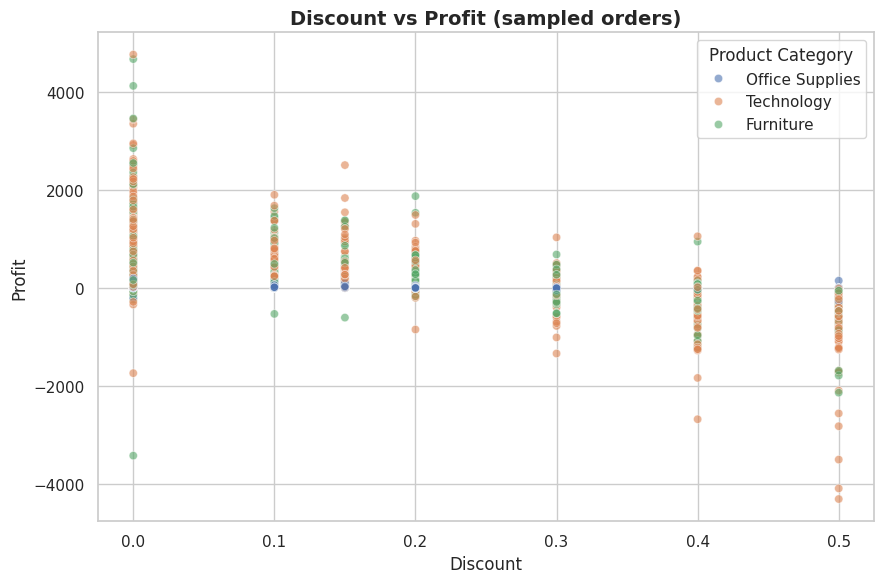

In [24]:
plt.figure(figsize=(9, 6))
sample = df.sample(min(3000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="Discount", y="Profit", hue="Product Category", alpha=0.6)
plt.title("Discount vs Profit (sampled orders)")
plt.tight_layout()
plt.savefig("eda_images/20_discount_vs_profit_scatter.png", dpi=120)
plt.show()

## 14. Key Takeaways

- Sales and profit are both right-skewed, driven by a relatively small number of large orders.
- Higher discount bands are associated with lower average profit — the data supports capping discounts around 20% for high-cost items.
- Furniture generates strong revenue but the weakest profit margin of the three categories.
- The West and East regions consistently outperform Central and South on both sales and profit.
- A small group of top customers accounts for a disproportionate share of total revenue.
- Shipping time is concentrated between 1-5 days, with a long tail beyond that worth investigating operationally.

These findings feed directly into the SQL business-insight queries (`MySQL/sql_queries.sql`) and the Power BI dashboard measures (`PowerBI/DAX_Measures.md`).
